# Miniprojeto Modulo 2


In [33]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time


# FASE 1 - Carregamento e Análise Exploratória de Imagens (EDA)

1 .Importar o dataset MNIST


In [34]:
print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


2. Dimensionalidade das matrizes (X e y) e distribuição das classes 


Shape X: (70000, 784)
Shape y: (70000,)

Tipo de dado das imagens: int64
Valor mínimo de pixel: 0, máximo: 255
Classes únicas: [0 1 2 3 4 5 6 7 8 9]
=== Dimensionalidade das matrizes ===
X: (70000, 784)  -> 70000 amostras, 784 features (pixels)
y: (70000,)

=== Distribuição das classes ===
   Dígito  Quantidade  Percentual
0       0        6903        9.86
1       1        7877       11.25
2       2        6990        9.99
3       3        7141       10.20
4       4        6824        9.75
5       5        6313        9.02
6       6        6876        9.82
7       7        7293       10.42
8       8        6825        9.75
9       9        6958        9.94


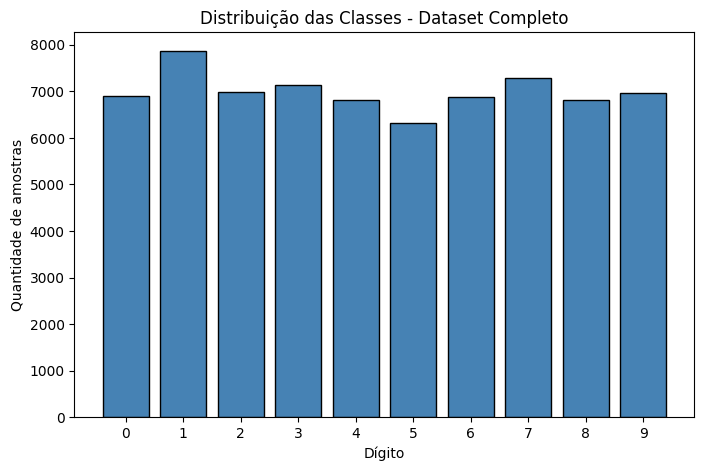

In [35]:
# Separando Entradas (X) e Rótulos (y)
X, y = mnist.data, mnist.target

# o y do fetch_openml vem como string ('0', '1', '2'...)
# por padrão, não como inteiro
y = y.astype(np.uint8)

print(f"Shape X: {X.shape}")   # (70000, 784) -> imagens já "achatadas" em vetores
print(f"Shape y: {y.shape}")   # (70000,)

print(f"\nTipo de dado das imagens: {X.dtype}")
print(f"Valor mínimo de pixel: {X.min()}, máximo: {X.max()}")
print(f"Classes únicas: {np.unique(y)}")

print("=== Dimensionalidade das matrizes ===")
print(f"X: {X.shape}  -> {X.shape[0]} amostras, {X.shape[1]} features (pixels)")
print(f"y: {y.shape}")

print("\n=== Distribuição das classes ===")
valores, contagens = np.unique(y, return_counts=True)
distribuicao = pd.DataFrame({'Dígito': valores, 'Quantidade': contagens})
distribuicao['Percentual'] = (distribuicao['Quantidade'] / distribuicao['Quantidade'].sum() * 100).round(2)
print(distribuicao)

plt.figure(figsize=(8, 5))
plt.bar(valores, contagens, color='steelblue', edgecolor='black')
plt.title('Distribuição das Classes - Dataset Completo')
plt.xlabel('Dígito')
plt.ylabel('Quantidade de amostras')
plt.xticks(valores)
plt.show()
plt.show()



O arquivo contém 70000 amostras de imagens com 784 vetores cada. As imagens contém os dígitos de 0 a 9 com uma quantidade de amostras muito próxima de cada dígito.

3. Grade visual 2 x 5 com matplotlib

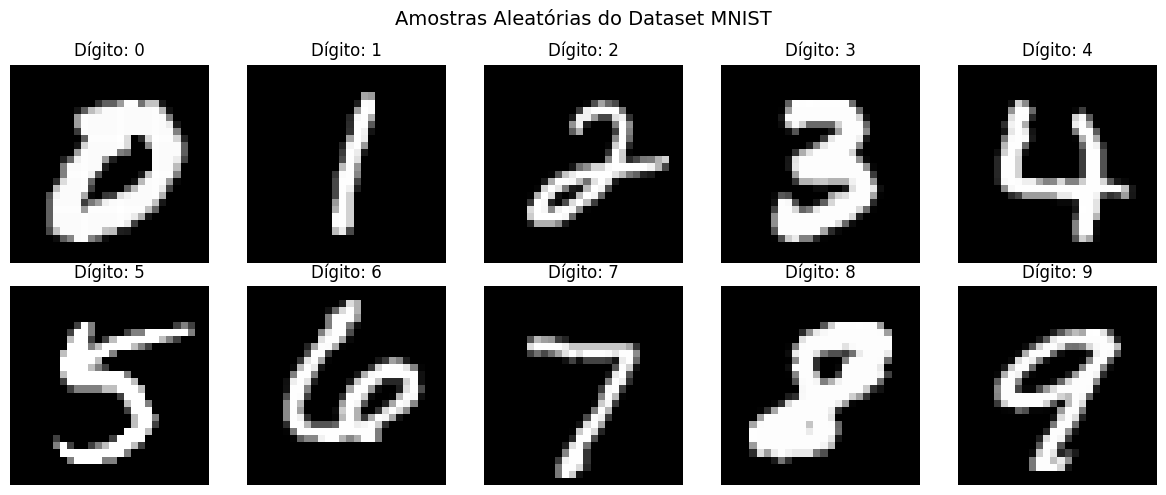

In [36]:
np.random.seed(42)  # para reprodutibilidade

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digito in range(10):
    # Pega todos os índices desse dígito e sorteia um aleatoriamente
    indices_digito = np.where(y == digito)[0]
    idx = np.random.choice(indices_digito)
    
    imagem = X[idx].reshape(28, 28)
    
    linha = digito // 5
    coluna = digito % 5
    
    axes[linha, coluna].imshow(imagem, cmap='gray')
    axes[linha, coluna].set_title(f'Dígito: {digito}')
    axes[linha, coluna].axis('off')

plt.suptitle('Amostras Aleatórias do Dataset MNIST', fontsize=14)
plt.tight_layout()
plt.show()

As imagens dos dígitos são com fundo preto e o dígito em si em branco.

4. Interpretação a estrutura dos dados: escala de intensidade de pixels (0 a 255), representação vetorial (784 featuras) das imagens bidimensionais (28 x 28)

ESCALA DE INTENSIDADE DE PIXELS: cada pixel da imagem é representado por números inteiros de 0 a 255, onde 0 é o preto absoluto (nenhuma intensidade luminosa) e 255 é o branco absoluto (intensidade máxima), e os valores intermediarios são tons de cinza. 

No caso do MNIST por convenção do dataset o fundo da imagem geralmente é preto (valores próximos de 0) e o traço do dígito escrito aparece em tons claros/brancos (valores próximos de 255) — o oposto de uma folha de papel real.

REPRESENTAÇÃO VETORIAL: Como os modelos clássicos não entendem matrizes 2D de imagem, cada imagem de 28 x 28 é achatada em uma linha com 784 colunas (28 x 28 = 784 variáveis numéricas)

# FASE 2 - Pipeline de Pré-processamento e Divisão dos Dados

1. Divisão estratificada (80% treino e 20% teste)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

print(f"X_train: {X_train.shape} ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"X_test:  {X_test.shape} ({X_test.shape[0]/X.shape[0]*100:.0f}%)")

# stratify=y mantém a proporção de dígitos entre treino e teste
prop_treino = pd.Series(y_train).value_counts(normalize=True).sort_index() * 100
prop_teste = pd.Series(y_test).value_counts(normalize=True).sort_index() * 100

comparacao = pd.DataFrame({'Treino (%)': prop_treino.round(2), 'Teste (%)': prop_teste.round(2)})
print("\n=== Comparação de proporções por classe ===")
print(comparacao)

X_train: (56000, 784) (80%)
X_test:  (14000, 784) (20%)

=== Comparação de proporções por classe ===
   Treino (%)  Teste (%)
0        9.86       9.86
1       11.25      11.25
2        9.99       9.99
3       10.20      10.20
4        9.75       9.75
5        9.02       9.02
6        9.82       9.82
7       10.42      10.42
8        9.75       9.75
9        9.94       9.94


2. Normalização / Escalonamento - pixels para a escala [0.0, 1.0]

In [38]:
# Normalização dos pixels (0-255 -> 0-1)
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("=== Normalização dos pixels ===")
print(f"Antes  -> min: {X_train.min()}, max: {X_train.max()}")
print(f"Depois -> min: {X_train_norm.min()}, max: {X_train_norm.max()}")

=== Normalização dos pixels ===
Antes  -> min: 0, max: 255
Depois -> min: 0.0, max: 1.0


3. Justificativa da importância da normalização

Redes neurais e a maioria dos algoritmos de otimização convergem muito mais rápido e de forma mais estável quando os valores de entrada estão numa escala pequena (0-1), em vez de 0-255

# FASE 3 - Implementação e Treinamento dos 3 modelos

1. Random Forest

In [39]:
# Treinamento do modelo
modelo_rf = RandomForestClassifier(
    n_estimators=100,      # número de árvores
    max_depth=None,        # número máximo de "galhos", profundidade
    random_state=42,
    n_jobs=-1              # usa todos os núcleos disponíveis do processador
)

print("Treinando o modelo...")
inicio = time.time()
modelo_rf.fit(X_train_norm, y_train)
fim = time.time()
print(f"Treinamento concluído em {fim - inicio:.2f} segundos")

# Avaliação
y_pred = modelo_rf.predict(X_test_norm)

acuracia = accuracy_score(y_test, y_pred)
print(f"\n=== Acurácia no teste: {acuracia*100:.2f}% ===")

print("\n=== Relatório de classificação ===")
print(classification_report(y_test, y_pred))

Treinando o modelo...
Treinamento concluído em 10.91 segundos

=== Acurácia no teste: 96.72% ===

=== Relatório de classificação ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.97      0.97      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.96      0.96      1365
           5       0.97      0.96      0.96      1263
           6       0.97      0.98      0.98      1375
           7       0.97      0.97      0.97      1459
           8       0.96      0.96      0.96      1365
           9       0.94      0.94      0.94      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



Ajustando hiperparametros para Random Forest com RandomizedSearchCV

In [40]:
# Espaço de busca de hiperparâmetros
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

busca_aleatoria = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,              # número de combinações testadas
    cv=3,                   # validação cruzada com 3 folds
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

print("Iniciando busca de hiperparâmetros...")
inicio = time.time()
busca_aleatoria.fit(X_train_norm, y_train)
fim = time.time()
print(f"Busca concluída em {(fim - inicio)/60:.1f} minutos")

print(f"\nMelhores hiperparâmetros: {busca_aleatoria.best_params_}")
print(f"Melhor acurácia (validação cruzada): {busca_aleatoria.best_score_*100:.2f}%")

# Avaliação do melhor modelo no conjunto de teste
melhor_modelo = busca_aleatoria.best_estimator_
y_pred_otimizado = melhor_modelo.predict(X_test_norm)

acuracia_final = accuracy_score(y_test, y_pred_otimizado)
print(f"\nAcurácia no teste (modelo otimizado): {acuracia_final*100:.2f}%")

Iniciando busca de hiperparâmetros...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Busca concluída em 10.5 minutos

Melhores hiperparâmetros: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Melhor acurácia (validação cruzada): 96.71%

Acurácia no teste (modelo otimizado): 96.86%


In [41]:
# Extrai os relatórios como dicionários
relatorio_1 = classification_report(y_test, y_pred, output_dict=True)
relatorio_2 = classification_report(y_test, y_pred_otimizado, output_dict=True)

# Monta um DataFrame comparando f1-score por classe
comparacao = pd.DataFrame({
    'Classe': [str(i) for i in range(10)],
    'F1 - Modelo 1': [relatorio_1[str(i)]['f1-score'] for i in range(10)],
    'F1 - Modelo 2': [relatorio_2[str(i)]['f1-score'] for i in range(10)],
})
comparacao['Diferença'] = comparacao['F1 - Modelo 2'] - comparacao['F1 - Modelo 1']
comparacao = comparacao.round(4)

print(comparacao)

print(f"\nAcurácia geral - Modelo 1: {relatorio_1['accuracy']*100:.2f}%")
print(f"Acurácia geral - Modelo 2: {relatorio_2['accuracy']*100:.2f}%")
print(f"Ganho: {(relatorio_2['accuracy'] - relatorio_1['accuracy'])*100:.2f} pontos percentuais")

  Classe  F1 - Modelo 1  F1 - Modelo 2  Diferença
0      0         0.9817         0.9814    -0.0004
1      1         0.9838         0.9838     0.0000
2      2         0.9653         0.9658     0.0004
3      3         0.9613         0.9642     0.0028
4      4         0.9644         0.9676     0.0032
5      5         0.9637         0.9662     0.0025
6      6         0.9772         0.9779     0.0007
7      7         0.9692         0.9708     0.0017
8      8         0.9586         0.9599     0.0013
9      9         0.9443         0.9457     0.0015

Acurácia geral - Modelo 1: 96.72%
Acurácia geral - Modelo 2: 96.86%
Ganho: 0.14 pontos percentuais


In [42]:
print("Hiperparâmetros do Modelo 1 (padrão):")
print(modelo_rf.get_params())

print("\nHiperparâmetros do Modelo 2 (otimizado):")
print(busca_aleatoria.best_params_)

print(f"\nScore de validação cruzada (Modelo 2): {busca_aleatoria.best_score_*100:.2f}%")
print(f"Acurácia no teste (Modelo 1): {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Acurácia no teste (Modelo 2): {accuracy_score(y_test, y_pred_otimizado)*100:.2f}%")


Hiperparâmetros do Modelo 1 (padrão):
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Hiperparâmetros do Modelo 2 (otimizado):
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}

Score de validação cruzada (Modelo 2): 96.71%
Acurácia no teste (Modelo 1): 96.72%
Acurácia no teste (Modelo 2): 96.86%


A utilização do RandomizedSearchCV trouxe um modelo melhor do que o inicial. As 30 combinações (n_iter=30) foram suficientes para explorar bem o espaço de busca.

2. KNN

In [43]:
# --- Treinamento do modelo ---
modelo_knn = KNeighborsClassifier(
    n_neighbors=5,      # número de vizinhos considerados (k)
    weights='uniform',  # todos os vizinhos têm peso igual no voto
    n_jobs=-1           # paraleliza o cálculo de distâncias
)

print("Treinando o modelo KNN...")
inicio = time.time()
modelo_knn.fit(X_train_norm, y_train)
fim = time.time()
print(f"'Treinamento' concluído em {fim - inicio:.2f} segundos")

# --- Avaliação ---
print("Realizando predições (pode demorar mais que o treino)...")
inicio_pred = time.time()
y_pred_knn = modelo_knn.predict(X_test_norm)
fim_pred = time.time()
print(f"Predição concluída em {fim_pred - inicio_pred:.2f} segundos")

acuracia_knn = accuracy_score(y_test, y_pred_knn)
print(f"\n=== Acurácia no teste: {acuracia_knn*100:.2f}% ===")

print("\n=== Relatório de classificação ===")
print(classification_report(y_test, y_pred_knn))

Treinando o modelo KNN...
'Treinamento' concluído em 0.06 segundos
Realizando predições (pode demorar mais que o treino)...
Predição concluída em 17.26 segundos

=== Acurácia no teste: 96.96% ===

=== Relatório de classificação ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1381
           1       0.95      0.99      0.97      1575
           2       0.99      0.95      0.97      1398
           3       0.97      0.97      0.97      1428
           4       0.98      0.96      0.97      1365
           5       0.96      0.96      0.96      1263
           6       0.97      0.99      0.98      1375
           7       0.96      0.98      0.97      1459
           8       0.99      0.93      0.96      1365
           9       0.96      0.96      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [44]:
# Espaço de busca de hiperparâmetros
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    }

busca_knn = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1, metric='euclidean'),
    param_grid=param_grid_knn,
    cv=3,                # 3 folds (KNN já é lento, cv maior deixaria muito demorado)
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

print("Iniciando busca de hiperparâmetros para o KNN (grid reduzido)...")
print("4 x 2 = 8 combinações x 3 folds = 24 execuções")

inicio = time.time()
busca_knn.fit(X_train_norm, y_train)
fim = time.time()
print(f"Busca concluída em {(fim - inicio)/60:.1f} minutos")

print(f"\nMelhores hiperparâmetros: {busca_knn.best_params_}")
print(f"Melhor acurácia (validação cruzada): {busca_knn.best_score_*100:.2f}%")

# Avaliação do melhor modelo no conjunto de teste
melhor_knn = busca_knn.best_estimator_
y_pred_knn_otimizado = melhor_knn.predict(X_test_norm)

acuracia_final_knn = accuracy_score(y_test, y_pred_knn_otimizado)
print(f"\nAcurácia no teste (KNN otimizado): {acuracia_final_knn*100:.2f}%")
print(f"Acurácia no teste (KNN padrão, k=5): {acuracia_knn*100:.2f}%")

Iniciando busca de hiperparâmetros para o KNN (grid reduzido)...
4 x 2 = 8 combinações x 3 folds = 24 execuções
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Busca concluída em 4.4 minutos

Melhores hiperparâmetros: {'n_neighbors': 5, 'weights': 'distance'}
Melhor acurácia (validação cruzada): 96.89%

Acurácia no teste (KNN otimizado): 97.08%
Acurácia no teste (KNN padrão, k=5): 96.96%


A busca por hiperparâmetros melhorou a acurácia do modelo.

3. Rede Neural Perceptron multicamadas 

In [45]:
# Treinamento do modelo
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # duas camadas ocultas: 128 e 64 neurônios
    activation='relu',              # função de ativação
    solver='adam',                  # otimizador
    max_iter=50,                    # número máximo de épocas
    random_state=42,
    early_stopping=True,            # para o treino se parar de melhorar (evita overfitting/perda de tempo)
    verbose=True
)

print("Treinando o modelo MLP...")
inicio = time.time()
modelo_mlp.fit(X_train_norm, y_train)
fim = time.time()
print(f"Treinamento concluído em {(fim - inicio)/60:.1f} minutos")

# --- Avaliação ---
y_pred_mlp = modelo_mlp.predict(X_test_norm)

acuracia_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"\n=== Acurácia no teste: {acuracia_mlp*100:.2f}% ===")

print("\n=== Relatório de classificação ===")
print(classification_report(y_test, y_pred_mlp))

Treinando o modelo MLP...
Iteration 1, loss = 0.41564310
Validation score: 0.943929
Iteration 2, loss = 0.16504833
Validation score: 0.956429
Iteration 3, loss = 0.11740894
Validation score: 0.966607
Iteration 4, loss = 0.08915566
Validation score: 0.971429
Iteration 5, loss = 0.07120661
Validation score: 0.972857
Iteration 6, loss = 0.05660975
Validation score: 0.968750
Iteration 7, loss = 0.04648725
Validation score: 0.971429
Iteration 8, loss = 0.03728203
Validation score: 0.969286
Iteration 9, loss = 0.03046723
Validation score: 0.970357
Iteration 10, loss = 0.02562315
Validation score: 0.975000
Iteration 11, loss = 0.02166668
Validation score: 0.973929
Iteration 12, loss = 0.01744920
Validation score: 0.974107
Iteration 13, loss = 0.01444082
Validation score: 0.973571
Iteration 14, loss = 0.01181757
Validation score: 0.974286
Iteration 15, loss = 0.01038697
Validation score: 0.970714
Iteration 16, loss = 0.01062334
Validation score: 0.971071
Iteration 17, loss = 0.00887416
Validat

# FASE 4 - Avaliação Comparativa de Desempenho

1. Matriz de confusão com mapa de calor

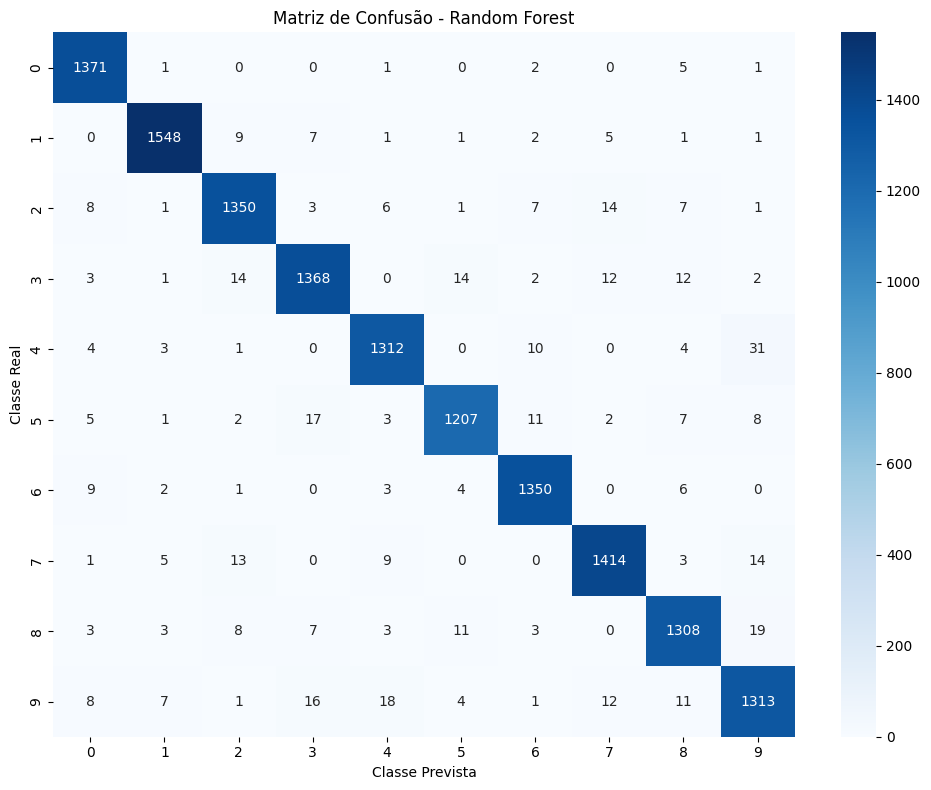

In [46]:
# Calculando a matriz de confusão
matriz = confusion_matrix(y_test, y_pred)

# Visualização com heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

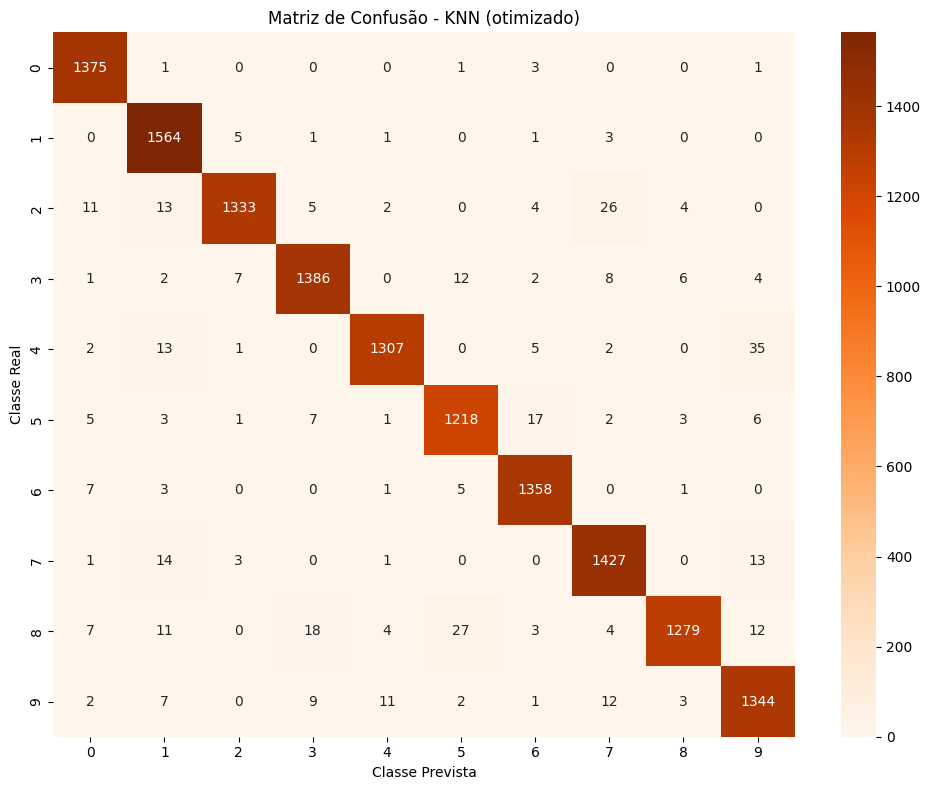

In [47]:
# Calculando a matriz de confusão
matriz_knn = confusion_matrix(y_test, y_pred_knn_otimizado)

# Visualização com heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusão - KNN (otimizado)')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

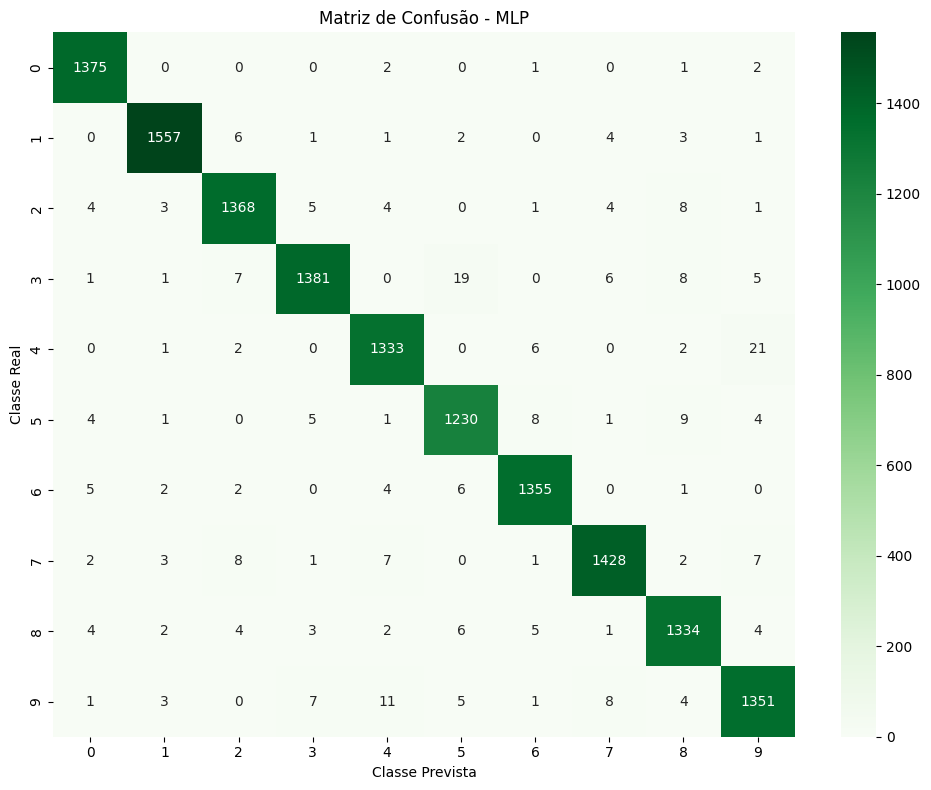

In [48]:
# Calculando a matriz de confusão
matriz_mlp = confusion_matrix(y_test, y_pred_mlp)

# Visualização com heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_mlp, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matriz de Confusão - MLP')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

2. Tabela comparativa (classification_report)
    - Acurácia Global
    - Precisão media ponderada
    - Revocação/ Sensibilidade média ponderada
    - F1 - Score ponderado




=== Acurácia Geral ===
Random Forest (otimizado): 96.86%
KNN (otimizado): 97.08%
MLP: 97.94%

=== F1-Score por Classe ===
  Classe  F1 - Random Forest  F1 - KNN  F1 - MLP
0      0              0.9814    0.9850    0.9903
1      1              0.9838    0.9757    0.9892
2      2              0.9658    0.9702    0.9789
3      3              0.9642    0.9713    0.9756
4      4              0.9676    0.9707    0.9766
5      5              0.9662    0.9636    0.9719
6      6              0.9779    0.9809    0.9844
7      7              0.9708    0.9698    0.9811
8      8              0.9599    0.9613    0.9748
9      9              0.9457    0.9579    0.9695

=== Médias (macro avg) ===
Random Forest -> Precision: 0.9684 | Recall: 0.9683 | F1: 0.9683
KNN           -> Precision: 0.9712 | Recall: 0.9704 | F1: 0.9706
MLP           -> Precision: 0.9792 | Recall: 0.9793 | F1: 0.9792


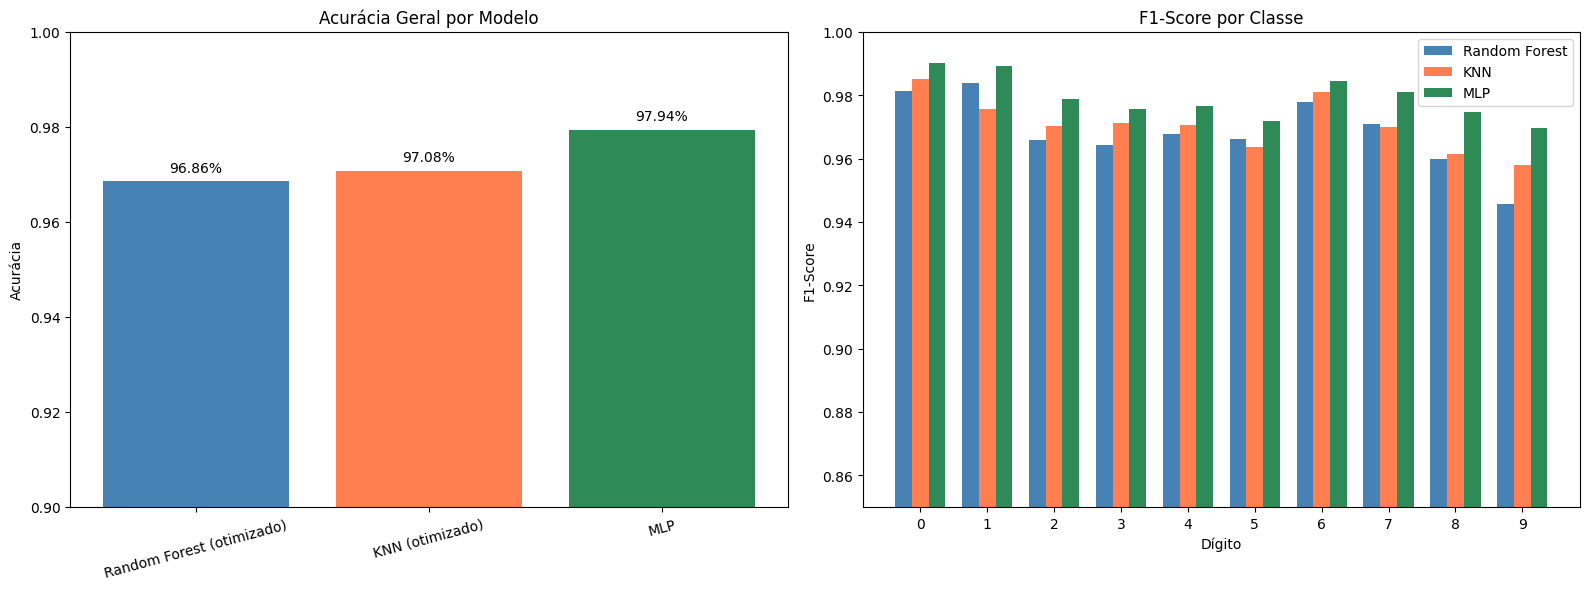

In [49]:
# Acurácia geral
resultados = {
    'Random Forest (otimizado)': accuracy_score(y_test, y_pred_otimizado),
    'KNN (otimizado)': accuracy_score(y_test, y_pred_knn_otimizado),
    'MLP': accuracy_score(y_test, y_pred_mlp)
}

print("=== Acurácia Geral ===")
for modelo, acc in resultados.items():
    print(f"{modelo}: {acc*100:.2f}%")

# Tabela comparativa de F1-score por classe
rel_rf = classification_report(y_test, y_pred_otimizado, output_dict=True)
rel_knn = classification_report(y_test, y_pred_knn_otimizado, output_dict=True)
rel_mlp = classification_report(y_test, y_pred_mlp, output_dict=True)

comparacao = pd.DataFrame({
    'Classe': [str(i) for i in range(10)],
    'F1 - Random Forest': [rel_rf[str(i)]['f1-score'] for i in range(10)],
    'F1 - KNN': [rel_knn[str(i)]['f1-score'] for i in range(10)],
    'F1 - MLP': [rel_mlp[str(i)]['f1-score'] for i in range(10)],
}).round(4)

print("\n=== F1-Score por Classe ===")
print(comparacao)

print("\n=== Médias (macro avg) ===")
print(f"Random Forest -> Precision: {rel_rf['macro avg']['precision']:.4f} | "
      f"Recall: {rel_rf['macro avg']['recall']:.4f} | F1: {rel_rf['macro avg']['f1-score']:.4f}")
print(f"KNN           -> Precision: {rel_knn['macro avg']['precision']:.4f} | "
      f"Recall: {rel_knn['macro avg']['recall']:.4f} | F1: {rel_knn['macro avg']['f1-score']:.4f}")
print(f"MLP           -> Precision: {rel_mlp['macro avg']['precision']:.4f} | "
      f"Recall: {rel_mlp['macro avg']['recall']:.4f} | F1: {rel_mlp['macro avg']['f1-score']:.4f}")

# Gráfico de barras: acurácia geral
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(resultados.keys(), resultados.values(), color=['steelblue', 'coral', 'seagreen'])
axes[0].set_title('Acurácia Geral por Modelo')
axes[0].set_ylabel('Acurácia')
axes[0].set_ylim(0.9, 1.0)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(resultados.values()):
    axes[0].text(i, v + 0.002, f'{v*100:.2f}%', ha='center')

# Gráfico de barras: F1-score por classe
x = np.arange(10)
largura = 0.25

axes[1].bar(x - largura, comparacao['F1 - Random Forest'], largura, label='Random Forest', color='steelblue')
axes[1].bar(x, comparacao['F1 - KNN'], largura, label='KNN', color='coral')
axes[1].bar(x + largura, comparacao['F1 - MLP'], largura, label='MLP', color='seagreen')
axes[1].set_xlabel('Dígito')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score por Classe')
axes[1].set_xticks(x)
axes[1].legend()
axes[1].set_ylim(0.85, 1.0)

plt.tight_layout()
plt.show()

=== Tabela Resumo Final ===
                   Modelo  Acurácia (%)  Tempo Predição (s)
Random Forest (otimizado)        96.857               0.641
          KNN (otimizado)        97.079              11.496
                      MLP        97.943               0.036


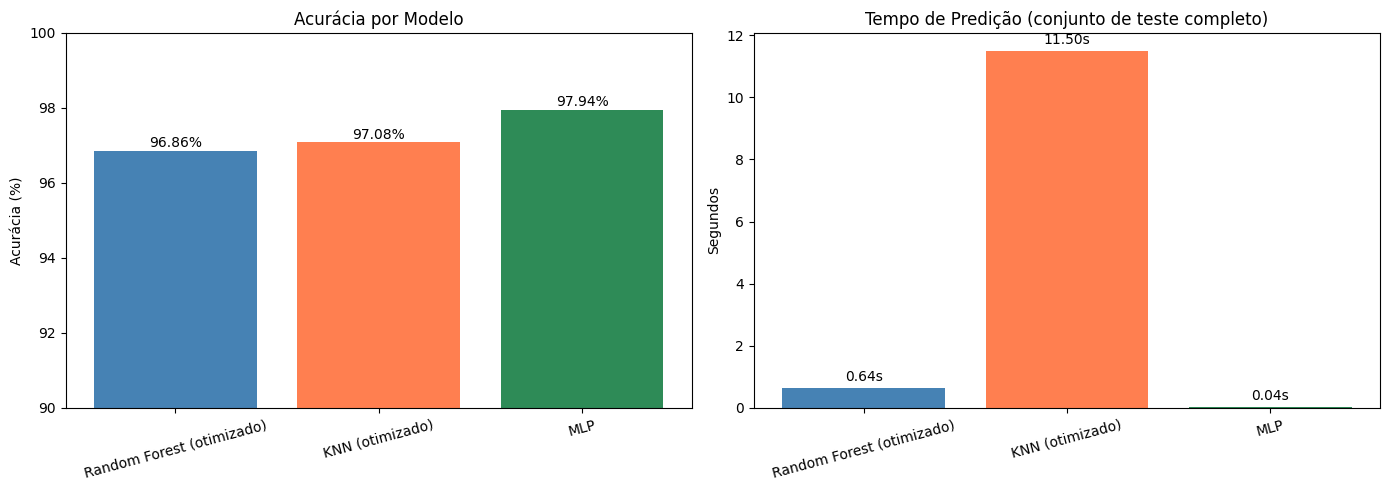

In [50]:
# Medindo tempo de predição de cada modelo já treinado

inicio = time.time()
_ = melhor_modelo.predict(X_test_norm)
tempo_pred_rf = time.time() - inicio

inicio = time.time()
_ = melhor_knn.predict(X_test_norm)
tempo_pred_knn = time.time() - inicio

inicio = time.time()
_ = modelo_mlp.predict(X_test_norm)
tempo_pred_mlp = time.time() - inicio

# Montando a tabela resumo
resumo = pd.DataFrame({
    'Modelo': ['Random Forest (otimizado)', 'KNN (otimizado)', 'MLP'],
    'Acurácia (%)': [
        accuracy_score(y_test, y_pred_otimizado) * 100,
        accuracy_score(y_test, y_pred_knn_otimizado) * 100,
        accuracy_score(y_test, y_pred_mlp) * 100
    ],
    'Tempo Predição (s)': [tempo_pred_rf, tempo_pred_knn, tempo_pred_mlp]
})

resumo = resumo.round(3)
print("=== Tabela Resumo Final ===")
print(resumo.to_string(index=False))

# --- Visualização ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(resumo['Modelo'], resumo['Acurácia (%)'], color=['steelblue', 'coral', 'seagreen'])
axes[0].set_title('Acurácia por Modelo')
axes[0].set_ylabel('Acurácia (%)')
axes[0].set_ylim(90, 100)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(resumo['Acurácia (%)']):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center')

axes[1].bar(resumo['Modelo'], resumo['Tempo Predição (s)'], color=['steelblue', 'coral', 'seagreen'])
axes[1].set_title('Tempo de Predição (conjunto de teste completo)')
axes[1].set_ylabel('Segundos')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(resumo['Tempo Predição (s)']):
    axes[1].text(i, v + max(resumo['Tempo Predição (s)'])*0.02, f'{v:.2f}s', ha='center')

plt.tight_layout()
plt.show()

O KNN tende a ter o pior tempo de predição do grupo, já que precisa calcular distância para todos os pontos de treino a cada nova predição.

Analisando a acurácia e o tempo de predição o melhor modelo é o de Rede Neural

# FASE 5 - Desafios

1. Treinamento restrito com classes ocultadas (class masking)

Classes ocultas no treino: [8, 9]
Classes usadas no treino: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7)]
Tamanho do treino original: 56000
Tamanho do treino restrito: 44973

=== Relatório no teste completo (incluindo classes ocultas) ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1381
           1       0.93      0.99      0.96      1575
           2       0.81      0.97      0.89      1398
           3       0.67      0.96      0.79      1428
           4       0.50      0.99      0.66      1365
           5       0.84      0.96      0.90      1263
           6       0.96      0.98      0.97      1375
           7       0.89      0.98      0.93      1459
           8       0.00      0.00      0.00      1365
           9       0.00      0.00      0.00      1391

    accuracy                           0.79     14000
   macro avg       0.65      0.78      0.71     1400

c:\Users\Yazigi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yazigi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yazigi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

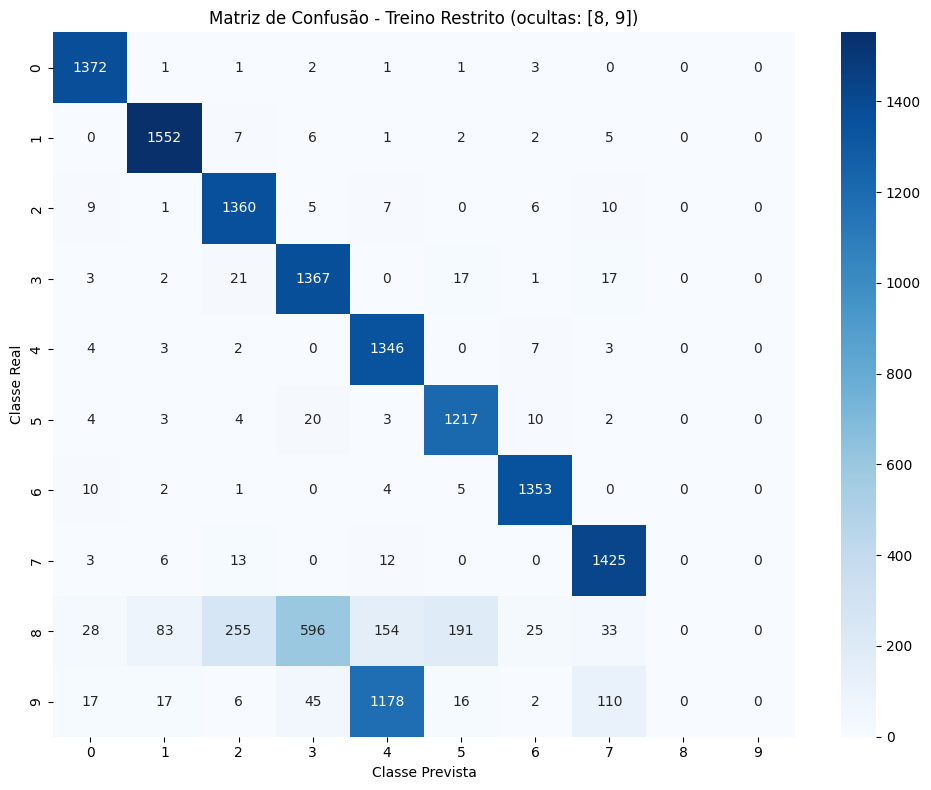

In [51]:
# Definindo quais classes ficarão ocultas no treino
classes_ocultas = [8, 9]

# Filtrando o conjunto de treino para remover essas classes
mascara_treino = ~np.isin(y_train, classes_ocultas)
X_train_restrito = X_train_norm[mascara_treino]
y_train_restrito = y_train[mascara_treino]

print(f"Classes ocultas no treino: {classes_ocultas}")
print(f"Classes usadas no treino: {sorted(np.unique(y_train_restrito))}")
print(f"Tamanho do treino original: {X_train_norm.shape[0]}")
print(f"Tamanho do treino restrito: {X_train_restrito.shape[0]}")

# Treinando o modelo apenas com as classes visíveis
modelo_restrito = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_restrito.fit(X_train_restrito, y_train_restrito)

# Avaliando no conjunto de teste COMPLETO (incluindo classes nunca vistas)
y_pred_restrito = modelo_restrito.predict(X_test_norm)

print("\n=== Relatório no teste completo (incluindo classes ocultas) ===")
print(classification_report(y_test, y_pred_restrito))

# Analisando especificamente o comportamento nas classes ocultas
mascara_teste_ocultas = np.isin(y_test, classes_ocultas)
y_teste_ocultas = y_test[mascara_teste_ocultas]
y_pred_ocultas = y_pred_restrito[mascara_teste_ocultas]

print(f"\n=== Para onde o modelo 'empurra' as classes ocultas ({classes_ocultas}) ===")
for classe in classes_ocultas:
    mask = y_teste_ocultas == classe
    previsoes = y_pred_ocultas[mask]
    valores, contagens = np.unique(previsoes, return_counts=True)
    print(f"\nDígito real {classe} (nunca visto no treino) foi classificado como:")
    for v, c in sorted(zip(valores, contagens), key=lambda x: -x[1]):
        print(f"  -> previsto como {v}: {c} vezes ({c/len(previsoes)*100:.1f}%)")

# Matriz de confusão completa, destacando as classes ocultas
matriz = confusion_matrix(y_test, y_pred_restrito, labels=range(10))
plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Matriz de Confusão - Treino Restrito (ocultas: {classes_ocultas})')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')

# Destaca visualmente as linhas das classes ocultas
for classe in classes_ocultas:
    plt.axhline(y=classe, color='red', linewidth=0, alpha=0)
    
plt.tight_layout()
plt.show()


=== Relatório KNN no teste completo (incluindo classes ocultas) ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1381
           1       0.90      0.99      0.95      1575
           2       0.88      0.96      0.92      1398
           3       0.70      0.97      0.82      1428
           4       0.62      0.98      0.76      1365
           5       0.75      0.97      0.85      1263
           6       0.96      0.99      0.97      1375
           7       0.68      0.99      0.81      1459
           8       0.00      0.00      0.00      1365
           9       0.00      0.00      0.00      1391

    accuracy                           0.79     14000
   macro avg       0.64      0.78      0.70     14000
weighted avg       0.65      0.79      0.71     14000


=== Para onde o KNN 'empurra' as classes ocultas ([8, 9]) ===

Dígito real 8 (nunca visto no treino) foi classificado como:
  -> previsto como 3: 546 vezes (40.0%)
  -> pre

c:\Users\Yazigi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yazigi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yazigi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

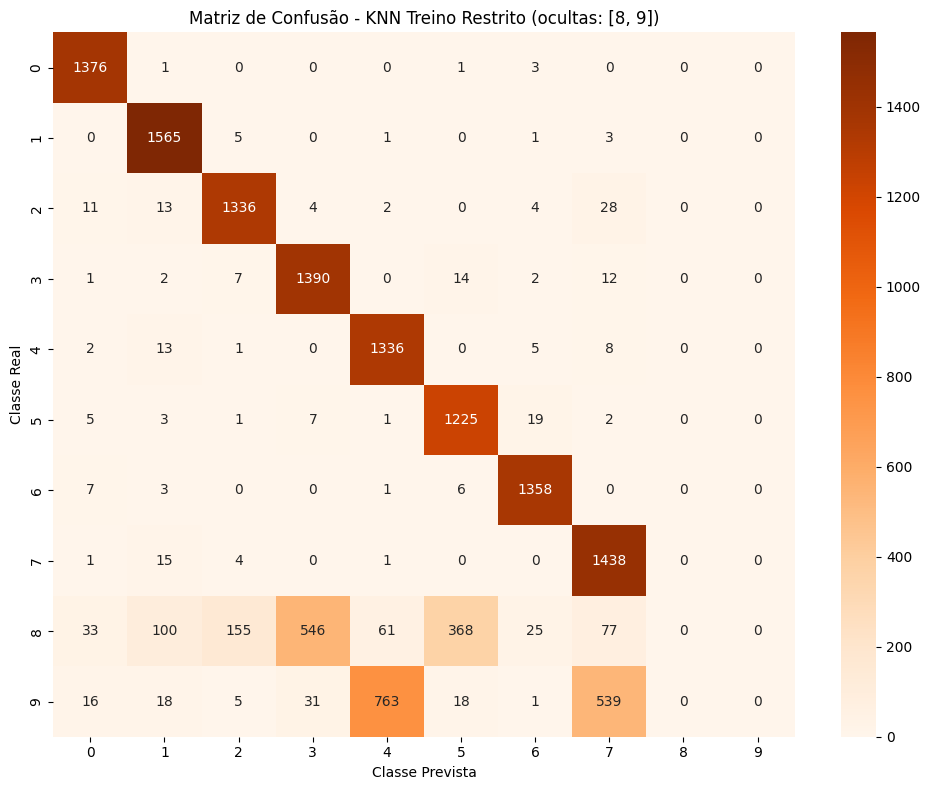

In [52]:
# Treinando o KNN apenas com as classes visíveis
# Usando os melhores hiperparâmetros já encontrados no GridSearchCV
modelo_knn_restrito = KNeighborsClassifier(**busca_knn.best_params_, n_jobs=-1)
modelo_knn_restrito.fit(X_train_restrito, y_train_restrito)

# Avaliando no conjunto de teste COMPLETO (incluindo classes nunca vistas)
y_pred_knn_restrito = modelo_knn_restrito.predict(X_test_norm)

print("=== Relatório KNN no teste completo (incluindo classes ocultas) ===")
print(classification_report(y_test, y_pred_knn_restrito))

# Analisando o comportamento nas classes ocultas
mascara_teste_ocultas = np.isin(y_test, classes_ocultas)
y_teste_ocultas = y_test[mascara_teste_ocultas]
y_pred_ocultas_knn = y_pred_knn_restrito[mascara_teste_ocultas]

print(f"\n=== Para onde o KNN 'empurra' as classes ocultas ({classes_ocultas}) ===")
for classe in classes_ocultas:
    mask = y_teste_ocultas == classe
    previsoes = y_pred_ocultas_knn[mask]
    valores, contagens = np.unique(previsoes, return_counts=True)
    print(f"\nDígito real {classe} (nunca visto no treino) foi classificado como:")
    for v, c in sorted(zip(valores, contagens), key=lambda x: -x[1]):
        print(f"  -> previsto como {v}: {c} vezes ({c/len(previsoes)*100:.1f}%)")

# Matriz de confusão
matriz_knn = confusion_matrix(y_test, y_pred_knn_restrito, labels=range(10))
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Matriz de Confusão - KNN Treino Restrito (ocultas: {classes_ocultas})')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

Treinando o MLP restrito...
Iteration 1, loss = 0.32017800
Validation score: 0.956203
Iteration 2, loss = 0.10991389
Validation score: 0.958871
Iteration 3, loss = 0.07603624
Validation score: 0.973988
Iteration 4, loss = 0.05749201
Validation score: 0.973099
Iteration 5, loss = 0.04293902
Validation score: 0.973321
Iteration 6, loss = 0.03383771
Validation score: 0.974433
Iteration 7, loss = 0.02665878
Validation score: 0.976212
Iteration 8, loss = 0.02139207
Validation score: 0.974878
Iteration 9, loss = 0.01721100
Validation score: 0.976656
Iteration 10, loss = 0.01290730
Validation score: 0.978880
Iteration 11, loss = 0.01094561
Validation score: 0.978435
Iteration 12, loss = 0.00835677
Validation score: 0.977990
Iteration 13, loss = 0.00635734
Validation score: 0.979546
Iteration 14, loss = 0.00576152
Validation score: 0.979769
Iteration 15, loss = 0.00429994
Validation score: 0.976212
Iteration 16, loss = 0.00443051
Validation score: 0.979324
Iteration 17, loss = 0.00236580
Valid

c:\Users\Yazigi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yazigi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Yazigi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

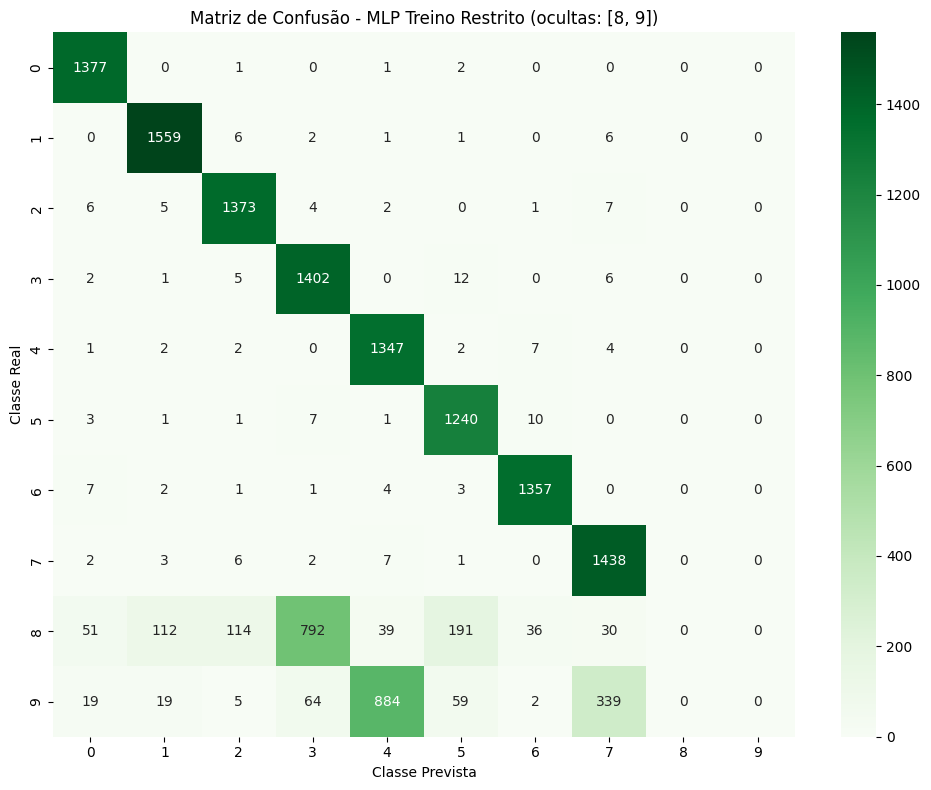

In [53]:
# Treinando o MLP apenas com as classes visíveis
modelo_mlp_restrito = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42,
    early_stopping=True,
    verbose=True
)

print("Treinando o MLP restrito...")
modelo_mlp_restrito.fit(X_train_restrito, y_train_restrito)

# Avaliando no conjunto de teste COMPLETO (incluindo classes nunca vistas)
y_pred_mlp_restrito = modelo_mlp_restrito.predict(X_test_norm)

print("\n=== Relatório MLP no teste completo (incluindo classes ocultas) ===")
print(classification_report(y_test, y_pred_mlp_restrito))

# Analisando o comportamento nas classes ocultas
mascara_teste_ocultas = np.isin(y_test, classes_ocultas)
y_teste_ocultas = y_test[mascara_teste_ocultas]
y_pred_ocultas_mlp = y_pred_mlp_restrito[mascara_teste_ocultas]

print(f"\n=== Para onde o MLP 'empurra' as classes ocultas ({classes_ocultas}) ===")
for classe in classes_ocultas:
    mask = y_teste_ocultas == classe
    previsoes = y_pred_ocultas_mlp[mask]
    valores, contagens = np.unique(previsoes, return_counts=True)
    print(f"\nDígito real {classe} (nunca visto no treino) foi classificado como:")
    for v, c in sorted(zip(valores, contagens), key=lambda x: -x[1]):
        print(f"  -> previsto como {v}: {c} vezes ({c/len(previsoes)*100:.1f}%)")

# Matriz de confusão
matriz_mlp = confusion_matrix(y_test, y_pred_mlp_restrito, labels=range(10))
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_mlp, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Matriz de Confusão - MLP Treino Restrito (ocultas: {classes_ocultas})')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

Dígito 8 → confundido majoritariamente com "3"

Os três modelos concordam: 8 é confundido principalmente com 3. Isso é um sinal forte de que essa não é uma peculiaridade de um algoritmo específico — é uma similaridade estrutural real entre os traços dos dígitos 8 e 3 (ambos têm curvas duplas/loops na região superior e inferior). O MLP foi o mais "convicto" nessa confusão (58%), enquanto RF e KNN distribuem um pouco mais o erro entre 3, 2 e 5.

Já o segundo lugar diverge:

RF e MLP: vão para 2 como segunda opção
KNN: vai para 5 como segunda opção (27%, bem mais que os outros)

Isso mostra a diferença de "métrica de similaridade" de cada algoritmo: o KNN compara pixels diretamente, e 8 e 5 têm sobreposição de forma física considerável (a parte inferior de ambos é parecida) — uma similaridade mais "literal" que RF e MLP não capturam tão fortemente.


Dígito 9 → confundido majoritariamente com "4"

Aqui a concordância é ainda mais forte — 9 e 4 compartilham o traço vertical com uma curva superior, uma confusão clássica em reconhecimento de dígitos manuscritos.

Ponto que mais chama atenção: o Random Forest ficou extremamente concentrado (84.7%) em "4", enquanto KNN dividiu bem mais entre 4 (54.9%) e 7 (38.7%). Isso sugere que o Random Forest aprendeu uma regra de decisão mais "rígida"/deterministica para essa região do espaço de features, enquanto o KNN — por comparar com exemplos reais — encontra vizinhos parecidos tanto com 4 quanto com 7 (que também tem traço reto vertical/diagonal), gerando mais incerteza real.

A confusão 8→3 e 9→4 não é um artefato do modelo — é uma limitação inerente da tarefa: sem ver exemplos de 8 e 9, todo classificador vai naturalmente mapear essas formas para a classe conhecida geometricamente mais próxima

Nenhum modelo demonstrou "incerteza" — todos "inventam" uma resposta com confiança: como vimos antes, isso é uma limitação estrutural de classificadores fechados (não têm opção de "não sei"/"classe desconhecida").

O MLP foi o mais "confiante" nos erros (58% e 63.6% concentrados numa única classe), sugerindo fronteiras de decisão mais suaves/generalizadas que "puxam" fortemente essas regiões para poucas classes específicas — enquanto o KNN, por depender de vizinhança local real, produz uma distribuição de erro mais heterogênea.



2. Teste de generalização extrema (inferência OOD)

O teste de generalização extrema com dados OOD (Out-of-Distribution) é diferente do que fizemos com as classes ocultas. Ali, o modelo ainda via dígitos manuscritos (só que de classes específicas). Agora, a ideia é submeter os modelos a entradas que não são dígitos manuscritos de verdade — ruído aleatório, formas geométricas, ou imagens de outro domínio -  para ver como eles reagem quando o dado é completamente estranho à distribuição de treino.

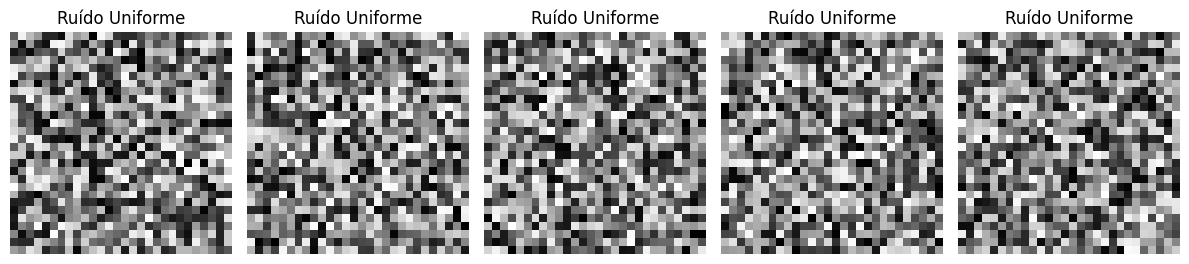

In [54]:
# Tipo 1: Ruído aleatório puro
np.random.seed(42)
ruido_uniforme = np.random.uniform(0, 1, size=(100, 784)).astype('float32')

# Visualizando alguns exemplos
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(ruido_uniforme[i].reshape(28, 28), cmap='gray')
    axes[i].set_title('Ruído Uniforme')
    axes[i].axis('off')
plt.tight_layout()
plt.show()


In [55]:
def testar_ood(modelo, dados_ood, nome_modelo, nome_dataset):
    predicoes = modelo.predict(dados_ood)
    
    if hasattr(modelo, 'predict_proba'):
        probabilidades = modelo.predict_proba(dados_ood)
        confianca_media = probabilidades.max(axis=1).mean()
    else:
        confianca_media = None
    
    valores, contagens = np.unique(predicoes, return_counts=True)
    
    print(f"\n=== {nome_modelo} em '{nome_dataset}' ===")
    print("Distribuição das predições:")
    for v, c in sorted(zip(valores, contagens), key=lambda x: -x[1]):
        print(f"  -> previsto como {v}: {c} vezes ({c/len(predicoes)*100:.1f}%)")
    
    if confianca_media is not None:
        print(f"Confiança média da predição (probabilidade máxima): {confianca_media*100:.2f}%")

# Testando com ruído uniforme
testar_ood(melhor_modelo, ruido_uniforme, "Random Forest", "Ruído Uniforme")
testar_ood(melhor_knn, ruido_uniforme, "KNN", "Ruído Uniforme")
testar_ood(modelo_mlp, ruido_uniforme, "MLP", "Ruído Uniforme")


=== Random Forest em 'Ruído Uniforme' ===
Distribuição das predições:
  -> previsto como 8: 100 vezes (100.0%)
Confiança média da predição (probabilidade máxima): 28.37%

=== KNN em 'Ruído Uniforme' ===
Distribuição das predições:
  -> previsto como 8: 32 vezes (32.0%)
  -> previsto como 2: 18 vezes (18.0%)
  -> previsto como 0: 14 vezes (14.0%)
  -> previsto como 3: 11 vezes (11.0%)
  -> previsto como 5: 11 vezes (11.0%)
  -> previsto como 6: 10 vezes (10.0%)
  -> previsto como 9: 3 vezes (3.0%)
  -> previsto como 4: 1 vezes (1.0%)
Confiança média da predição (probabilidade máxima): 62.01%

=== MLP em 'Ruído Uniforme' ===
Distribuição das predições:
  -> previsto como 5: 100 vezes (100.0%)
Confiança média da predição (probabilidade máxima): 99.89%


O modelo Random Forest colapsa, mas com confiança baixa, com risco moderado, já que a baixa confiança é um sinal de alerta útil.

O KNN distribui as previsões, tem confiança intermediária, e risco moderado pois a dispersão sugere instabilidade, mas ainda não é um "alerta" claro.

Já o MLP colapsa com confiança quase perfeita, com risco alto, gerenado o pior cenário possível com erro silencioso e "confiante".

Esse experimento demonstra bem por que, em aplicações reais, seria necessário um mecanismo dedicado de detecção de OOD, não bastando usar a confiança (predict_proba) do próprio modelo como critério.

3. Inferência com imagens manuscritas próprias

In [56]:
from PIL import Image

def preparar_imagem_propria(caminho_arquivo, rotacao=0):
    # Carrega e converte para escala de cinza
    img = Image.open(caminho_arquivo).convert('L')

    if rotacao != 0:
        img = img.rotate(rotacao, expand=True)
    
    # Redimensiona para 28x28 (tamanho do MNIST)
    img = img.resize((28, 28), Image.LANCZOS)
    
    img_array = np.array(img).astype('float32')
    
    # IMPORTANTE: o MNIST tem fundo PRETO (0) e dígito BRANCO (255)
    # Se sua foto tem fundo branco e traço preto, precisa INVERTER as cores
    img_array = 255 - img_array
    
    # Normalizando para 0-1 (mesma escala usada no treino)
    img_array = img_array / 255.0
    
    # Achatando para 784 features (formato usado pelo scikit-learn)
    img_vetor = img_array.reshape(1, 784)
    
    return img_vetor, img_array




Imagem 1: imagem a.jpg
Dígito real: 2
Random Forest: previu '8' (confiança: 28.0%)
KNN: previu '8' (confiança: 60.0%)
MLP: previu '5' (confiança: 100.0%)

Imagem 2: imagem b.jpg
Dígito real: 7
Random Forest: previu '8' (confiança: 30.3%)
KNN: previu '2' (confiança: 80.0%)
MLP: previu '5' (confiança: 100.0%)

Imagem 3: imagem c.jpg
Dígito real: 5
Random Forest: previu '8' (confiança: 29.3%)
KNN: previu '5' (confiança: 100.0%)
MLP: previu '5' (confiança: 100.0%)


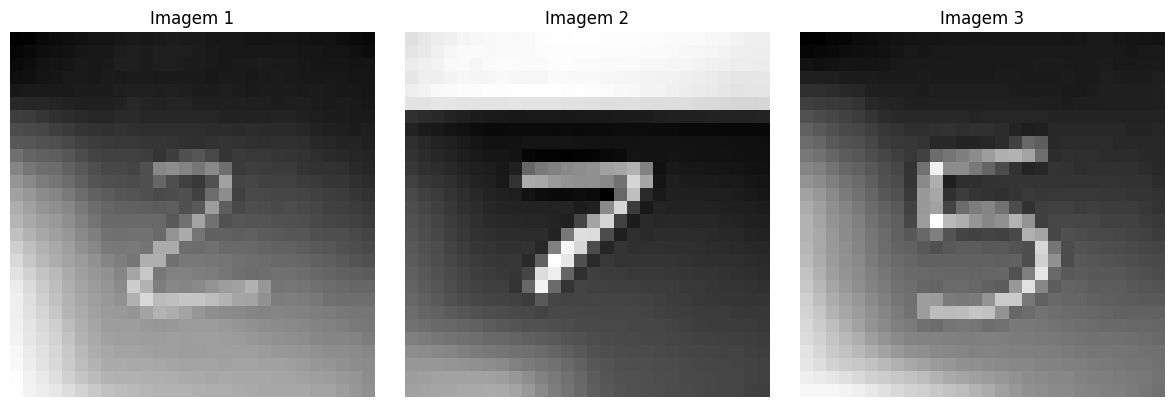

In [57]:
caminhos = [
    r'C:\Users\Yazigi\Documents\IA aulas\Miniprojeto modulo2\Miniprojeto_modulo2\imagem a.jpg',
    r'C:\Users\Yazigi\Documents\IA aulas\Miniprojeto modulo2\Miniprojeto_modulo2\imagem b.jpg',
    r'C:\Users\Yazigi\Documents\IA aulas\Miniprojeto modulo2\Miniprojeto_modulo2\imagem c.jpg',
]

# Se alguma imagem precisar de rotação, ajuste aqui (0 se não precisar)
rotacoes = [270, 270, 270]  

# Se você souber o dígito real de cada imagem, informe aqui (ou None se não souber)
digitos_reais = [2, 7, 5]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, (caminho, rot, real) in enumerate(zip(caminhos, rotacoes, digitos_reais)):
    img_vetor, img_visual = preparar_imagem_propria(caminho, rotacao=rot)
    
    axes[i].imshow(img_visual, cmap='gray')
    axes[i].axis('off')
    
    print(f"\n{'='*50}")
    print(f"Imagem {i+1}: {caminho.split(chr(92))[-1]}")
    if real is not None:
        print(f"Dígito real: {real}")
    
    for nome, modelo in [('Random Forest', melhor_modelo), 
                          ('KNN', melhor_knn), 
                          ('MLP', modelo_mlp)]:
        pred = modelo.predict(img_vetor)[0]
        
        if hasattr(modelo, 'predict_proba'):
            proba = modelo.predict_proba(img_vetor)[0]
            confianca = proba.max() * 100
            print(f"{nome}: previu '{pred}' (confiança: {confianca:.1f}%)")
        else:
            print(f"{nome}: previu '{pred}'")
    
    axes[i].set_title(f"Imagem {i+1}")

plt.tight_layout()
plt.show()

Conclui-se que depois do pré-processamento, as imagens não se parecem nada com um dígito MNIST do ponto de vista do modelo. Ou seja: os modelos estão reagindo exatamente como reagiram ao ruído puro, porque, na prática, a imagem processada virou algo próximo de ruído para eles.

As causas prováveis deste pré-processamento não funcionar são:
- Dígito não centralizado / desproporcional
- Inversão de cor incorreta ou inconsistente
- Espessura de traço e nitidez

Para verificar estes pontos foi feita uma nova imagem, mas agora a foto foi editada para que o branco ficasse mais branco e os traços do número foram feitos mais grossos.

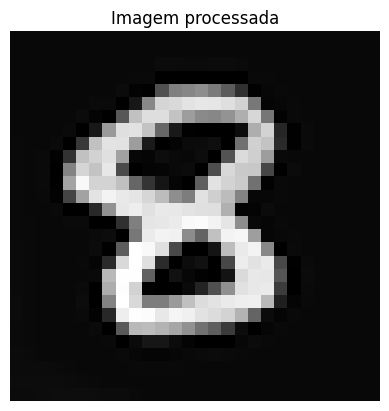

=== Predições para o dígito manuscrito ===
Dígito real (informado por você): 8

Random Forest: previu '8' (confiança: 37.7%)
KNN: previu '3' (confiança: 100.0%)
MLP: previu '8' (confiança: 100.0%)


In [59]:
def prever_digito_proprio(img_vetor, verdadeiro=None):
    print(f"=== Predições para o dígito manuscrito ===")
    if verdadeiro is not None:
        print(f"Dígito real (informado por você): {verdadeiro}\n")
    
    for nome, modelo in [('Random Forest', melhor_modelo), 
                          ('KNN', melhor_knn), 
                          ('MLP', modelo_mlp)]:
        pred = modelo.predict(img_vetor)[0]
        
        if hasattr(modelo, 'predict_proba'):
            proba = modelo.predict_proba(img_vetor)[0]
            confianca = proba.max() * 100
            print(f"{nome}: previu '{pred}' (confiança: {confianca:.1f}%)")
        else:
            print(f"{nome}: previu '{pred}'")

caminho = r'C:\Users\Yazigi\Documents\IA aulas\Miniprojeto modulo2\Miniprojeto_modulo2\imagem_ajustada.jpg'

# Teste ângulos até a imagem ficar correta: 90, 180 ou 270
img_vetor, img_visual = preparar_imagem_propria(caminho, rotacao=0)

plt.imshow(img_visual, cmap='gray')
plt.title('Imagem processada')
plt.axis('off')
plt.show()

prever_digito_proprio(img_vetor, verdadeiro=8)

O trabalho todo aponta para uma conclusão central: acurácia alta em dados de teste não garante segurança em produção. Um modelo pode ter ótima performance nos dados que "conhece" e ainda assim falhar silenciosamente (e com alta confiança) diante de entradas inesperadas — por isso, sistemas reais de classificação geralmente precisam de mecanismos adicionais de detecção de anomalias/OOD, não apenas confiar na saída de probabilidade do próprio modelo.